 # Uso de redes generativas para la mejora de la señal astronómica



 El presente jupyter notebook contiene el código usado para el entrenamiento y creación del modelo generativo.



# Extracción de los datos

 ### Datos filtrados de Gaia con SDSS

In [75]:
from pathlib import Path
from astroquery.gaia import Gaia
from astropy.table import Table

gaia_query_path = Path("services", "queries", "gaia_sdss_random_subset.adql")
gaia_query_template = gaia_query_path.read_text(encoding="utf-8")
gaia_query = gaia_query_template.format(start_index=0, end_index=10000)

print(f"Executing Step 1: {gaia_query_path.name}...")
gaia_query_job = Gaia.launch_job_async(gaia_query)
gaia_job_results = gaia_query_job.get_results() or Table()

display(gaia_job_results)

Executing Step 1: gaia_sdss_random_subset.adql...
INFO: Query finished. [astroquery.utils.tap.core]


source_id,ra,dec,phot_bp_mean_mag,phot_rp_mean_mag,original_ext_source_id,angular_distance
,deg,deg,mag,mag,,arcsec
int64,float64,float64,float32,float32,int64,float32
152075175521731328,65.72831483785296,26.54414677239031,17.397339,15.67181,1237660553838723452,0.09896018
1802312382146914944,304.44372864097727,11.814212331449525,17.850197,16.73824,1237666428280047734,0.051741824
3064808054479978496,126.70788872449542,-6.428045792609196,17.280102,16.331446,1237673708252037535,0.074501015
3326210827953204736,97.62465009763454,8.073994072482016,17.689917,16.489973,1237674284864374364,0.04954242
4206840648762711936,292.7129244817407,-7.7798093237759325,17.116796,15.607607,1237668709454122329,0.05537122
286684600242041088,87.93928734400812,62.81940357123728,16.359398,15.297744,1237667206210191919,0.0053555067
545845370721163264,40.35141976475039,72.60547698121222,12.949248,11.929797,1237671071143362774,0.040905617
869081242163178368,115.3424311509604,26.3651645520983,17.6026,16.80178,1237657401334169720,0.046761636


 ### Datos espectrales de Gaia



 Para los datos espectrales debemos usar el [DataLink service](https://astroquery.readthedocs.io/en/latest/gaia/gaia.html#datalink-service-public-and-authenticated)

 #### Obtención de los datos

In [66]:
source_ids = ",".join(gaia_job_results['source_id'].astype(str))

xp_data = Gaia.load_data(
    ids=source_ids,
    data_release="Gaia DR3",
    retrieval_type="XP_SAMPLED",
    # retrieval_type="XP_CONTINUOUS",
    data_structure="INDIVIDUAL",
    format="votable",
    dump_to_file=False, # Datos en memoria
)

display(xp_data)



{'XP_SAMPLED-Gaia DR3 1065122928444442752.xml': [<VOTable length=343>
  wavelength      flux       flux_error 
      nm      W / (nm m2)   W / (nm m2) 
   float64      float32       float32   
  ---------- ------------- -------------
       336.0 3.5054336e-17 3.8545847e-18
       338.0 3.4419846e-17 2.8654515e-18
       340.0  3.401084e-17 2.3531251e-18
       342.0 3.2432564e-17 2.0500412e-18
       344.0  3.099752e-17  1.948842e-18
       346.0 3.0659158e-17 1.9413135e-18
       348.0  3.111563e-17 2.0390585e-18
       350.0 3.0848013e-17  2.178113e-18
       352.0 3.1053578e-17 2.4208398e-18
         ...           ...           ...
      1004.0 2.0092826e-17  1.085377e-18
      1006.0 1.9653975e-17 1.1923356e-18
      1008.0  1.875103e-17 1.4298017e-18
      1010.0  1.805221e-17 1.7663724e-18
      1012.0 1.7515827e-17  2.103205e-18
      1014.0  1.687539e-17 2.3100261e-18
      1016.0 1.7029447e-17  2.436967e-18
      1018.0 1.7084375e-17 2.3445673e-18
      1020.0 1.8112651e-17 2

 #### Graficado de los datos

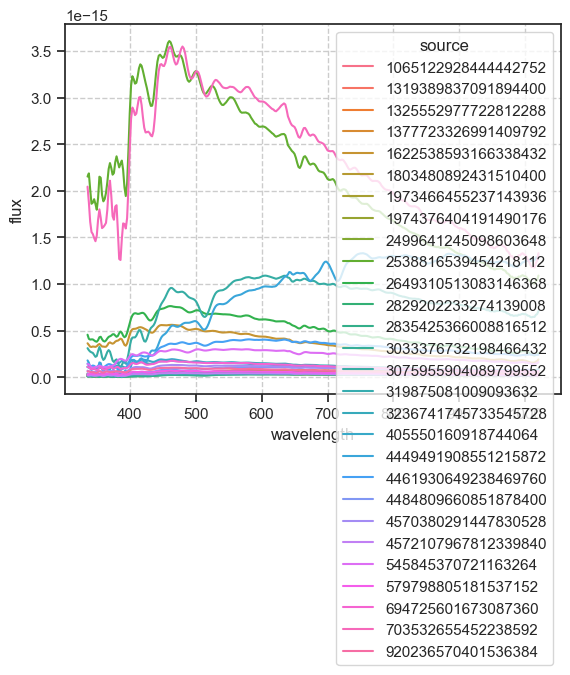

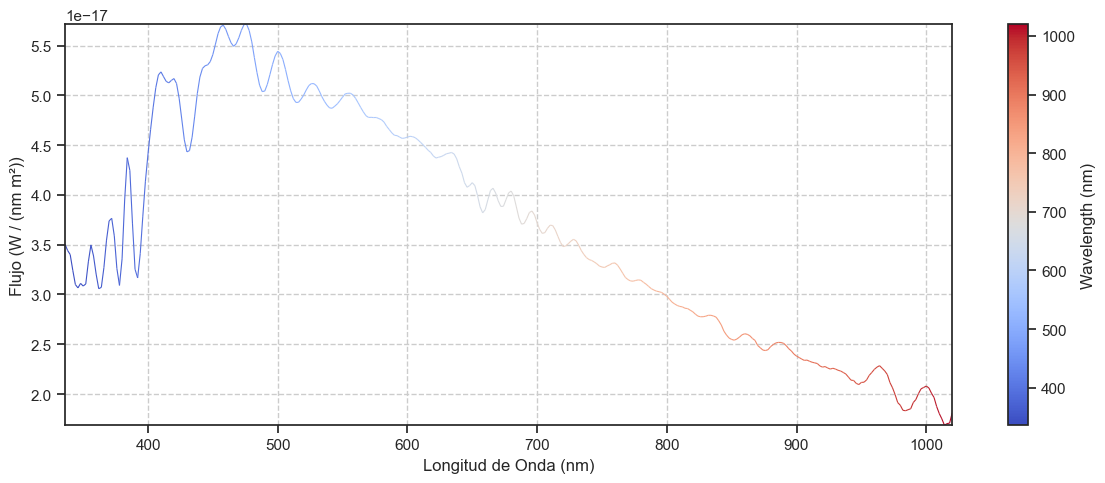

In [ ]:

## Ejemplo de múltiples sources
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.concat(
    [v[0].to_table().to_pandas().assign(
        source=key.split()[-1].replace('.xml', '')
    ) for key, v in xp_data.items()],
    ignore_index=True
)

sns.lineplot(data=df, x='wavelength', y='flux', hue='source')
plt.show()

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# 1. Build a flat DataFrame for a single spectrum (first source in xp_data)
first_key = next(iter(xp_data))
raw = xp_data[first_key][0].to_table().to_pandas()
spectrum_df = pd.DataFrame({
    'Wavelengt': raw['wavelength'],
    'Flux': raw['flux']
})

# 2. Set the aesthetic theme globally (same as your example)
sns.set_theme(style="ticks", rc={"axes.grid": True, "grid.linestyle": "--"})

plt.figure(figsize=(12, 5))

# 3. Plot a line whose colour changes from blue (short λ) to red (long λ) 
#    (Seaborn does not provide this directly; we use a LineCollection)
x = spectrum_df['Wavelengt'].values
y = spectrum_df['Flux'].values

norm = Normalize(vmin=x.min(), vmax=x.max())
cmap = plt.get_cmap('coolwarm')          # blue -> red

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=0.8)
lc.set_array(x)                           # colour each segment by its x-start
plt.gca().add_collection(lc)

# 4. Axis labels and limits
plt.xlabel('Longitud de Onda (nm)')
plt.ylabel('Flujo (W / (nm m²))')
plt.xlim(x.min(), x.max())
plt.ylim(y.min(), y.max())

# Optional colour bar to show the mapping
cbar = plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=plt.gca())
cbar.set_label('Wavelength (nm)')

plt.tight_layout()
plt.show()



In [ ]:
import re
from astroquery.sdss import SDSS
from astropy.io import ascii
from astropy.table import Table

def sanitize_adql(raw_query: str) -> str:
    """Removes SQL comments and compresses whitespace into single spaces."""
    # 1. Remove block comments (/* ... */)
    # The re.DOTALL flag allows '.' to match newline characters
    no_blocks = re.sub(r'/\*.*?\*/', '', raw_query, flags=re.DOTALL)
    
    # 2. Remove inline comments (-- ...)
    no_inlines = re.sub(r'--.*', '', no_blocks)
    
    # 3. Compress remaining whitespace (tabs, newlines, multiple spaces)
    return re.sub(r'\s+', ' ', no_inlines).strip()

gaia_crossmatch_ids = gaia_job_results["original_ext_source_id"]
query_filter_ids = ",".join(gaia_crossmatch_ids.astype(str))

sdss_query_path = Path("services", "queries", "sdss.adql")
sdss_query_template = sdss_query_path.read_text(encoding="utf-8")
sdss_query_template_sanitized = sanitize_adql(sdss_query_template)
sdss_query = sdss_query_template_sanitized.format(filter_ids=query_filter_ids)

sdss_query_result = SDSS.query_sql(sdss_query, data_release=13)

# print(sdss_query_result.keys.filter['flux'])

display(sdss_query_result)



objID,specObjID,plate,mjd,fiberID,redshift,objID1,skyVersion,run,rerun,camcol,field,obj,mode,nChild,type,clean,probPSF,insideMask,flags,rowc,rowcErr,colc,colcErr,rowv,rowvErr,colv,colvErr,rowc_u,rowc_g,rowc_r,rowc_i,rowc_z,rowcErr_u,rowcErr_g,rowcErr_r,rowcErr_i,rowcErr_z,colc_u,colc_g,colc_r,colc_i,colc_z,colcErr_u,colcErr_g,colcErr_r,colcErr_i,colcErr_z,sky_u,sky_g,sky_r,sky_i,sky_z,skyIvar_u,skyIvar_g,skyIvar_r,skyIvar_i,skyIvar_z,psfMag_u,psfMag_g,psfMag_r,psfMag_i,psfMag_z,psfMagErr_u,psfMagErr_g,psfMagErr_r,psfMagErr_i,psfMagErr_z,fiberMag_u,fiberMag_g,fiberMag_r,fiberMag_i,fiberMag_z,fiberMagErr_u,fiberMagErr_g,fiberMagErr_r,fiberMagErr_i,fiberMagErr_z,fiber2Mag_u,fiber2Mag_g,fiber2Mag_r,fiber2Mag_i,fiber2Mag_z,fiber2MagErr_u,fiber2MagErr_g,fiber2MagErr_r,fiber2MagErr_i,fiber2MagErr_z,petroMag_u,petroMag_g,petroMag_r,petroMag_i,petroMag_z,petroMagErr_u,petroMagErr_g,petroMagErr_r,petroMagErr_i,petroMagErr_z,psfFlux_u,psfFlux_g,psfFlux_r,psfFlux_i,psfFlux_z,psfFluxIvar_u,psfFluxIvar_g,psfFluxIvar_r,psfFluxIvar_i,psfFluxIvar_z,fiberFlux_u,fiberFlux_g,fiberFlux_r,fiberFlux_i,fiberFlux_z,fiberFluxIvar_u,fiberFluxIvar_g,fiberFluxIvar_r,fiberFluxIvar_i,fiberFluxIvar_z,fiber2Flux_u,fiber2Flux_g,fiber2Flux_r,fiber2Flux_i,fiber2Flux_z,fiber2FluxIvar_u,fiber2FluxIvar_g,fiber2FluxIvar_r,fiber2FluxIvar_i,fiber2FluxIvar_z,petroFlux_u,petroFlux_g,petroFlux_r,petroFlux_i,petroFlux_z,petroFluxIvar_u,petroFluxIvar_g,petroFluxIvar_r,petroFluxIvar_i,petroFluxIvar_z,petroRad_u,petroRad_g,petroRad_r,petroRad_i,petroRad_z,petroRadErr_u,petroRadErr_g,petroRadErr_r,petroRadErr_i,petroRadErr_z,petroR50_u,petroR50_g,petroR50_r,petroR50_i,petroR50_z,petroR50Err_u,petroR50Err_g,petroR50Err_r,petroR50Err_i,petroR50Err_z,petroR90_u,petroR90_g,petroR90_r,petroR90_i,petroR90_z,petroR90Err_u,petroR90Err_g,petroR90Err_r,petroR90Err_i,petroR90Err_z,q_u,q_g,q_r,q_i,q_z,qErr_u,qErr_g,qErr_r,qErr_i,qErr_z,u_u,u_g,u_r,u_i,u_z,uErr_u,uErr_g,uErr_r,uErr_i,uErr_z,mE1_u,mE1_g,mE1_r,mE1_i,mE1_z,mE2_u,mE2_g,mE2_r,mE2_i,mE2_z,mE1E1Err_u,mE1E1Err_g,mE1E1Err_r,mE1E1Err_i,mE1E1Err_z,mE1E2Err_u,mE1E2Err_g,mE1E2Err_r,mE1E2Err_i,mE1E2Err_z,mE2E2Err_u,mE2E2Err_g,mE2E2Err_r,mE2E2Err_i,mE2E2Err_z,mRrCc_u,mRrCc_g,mRrCc_r,mRrCc_i,mRrCc_z,mRrCcErr_u,mRrCcErr_g,mRrCcErr_r,mRrCcErr_i,mRrCcErr_z,mCr4_u,mCr4_g,mCr4_r,mCr4_i,mCr4_z,mE1PSF_u,mE1PSF_g,mE1PSF_r,mE1PSF_i,mE1PSF_z,mE2PSF_u,mE2PSF_g,mE2PSF_r,mE2PSF_i,mE2PSF_z,mRrCcPSF_u,mRrCcPSF_g,mRrCcPSF_r,mRrCcPSF_i,mRrCcPSF_z,mCr4PSF_u,mCr4PSF_g,mCr4PSF_r,mCr4PSF_i,mCr4PSF_z,deVRad_u,deVRad_g,deVRad_r,deVRad_i,deVRad_z,deVRadErr_u,deVRadErr_g,deVRadErr_r,deVRadErr_i,deVRadErr_z,deVAB_u,deVAB_g,deVAB_r,deVAB_i,deVAB_z,deVABErr_u,deVABErr_g,deVABErr_r,deVABErr_i,deVABErr_z,deVPhi_u,deVPhi_g,deVPhi_r,deVPhi_i,deVPhi_z,deVMag_u,deVMag_g,deVMag_r,deVMag_i,deVMag_z,deVMagErr_u,deVMagErr_g,deVMagErr_r,deVMagErr_i,deVMagErr_z,deVFlux_u,deVFlux_g,deVFlux_r,deVFlux_i,deVFlux_z,deVFluxIvar_u,deVFluxIvar_g,deVFluxIvar_r,deVFluxIvar_i,deVFluxIvar_z,expRad_u,expRad_g,expRad_r,expRad_i,expRad_z,expRadErr_u,expRadErr_g,expRadErr_r,expRadErr_i,expRadErr_z,expAB_u,expAB_g,expAB_r,expAB_i,expAB_z,expABErr_u,expABErr_g,expABErr_r,expABErr_i,expABErr_z,expPhi_u,expPhi_g,expPhi_r,expPhi_i,expPhi_z,expMag_u,expMag_g,expMag_r,expMag_i,expMag_z,expMagErr_u,expMagErr_g,expMagErr_r,expMagErr_i,expMagErr_z,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,modelMagErr_u,modelMagErr_g,modelMagErr_r,modelMagErr_i,modelMagErr_z,cModelMag_u,cModelMag_g,cModelMag_r,cModelMag_i,cModelMag_z,cModelMagErr_u,cModelMagErr_g,cModelMagErr_r,cModelMagErr_i,cModelMagErr_z,expFlux_u,expFlux_g,expFlux_r,expFlux_i,expFlux_z,expFluxIvar_u,expFluxIvar_g,expFluxIvar_r,expFluxIvar_i,expFluxIvar_z,modelFlux_u,modelFlux_g,modelFlux_r,modelFlux_i,modelFlux_z,modelFluxIvar_u,modelFluxIvar_g,modelFluxIvar_r,modelFluxIvar_i,modelFluxIvar_z,cModelFlux_u,cModelFlux_g,cModelFlux_r,cModelFlux_i,cModelFlux_z,cModelFluxIvar_u,cModelFluxIvar_g,cModelFluxIvar_r,cModelFluxIvar_i,cModelFluxIvar

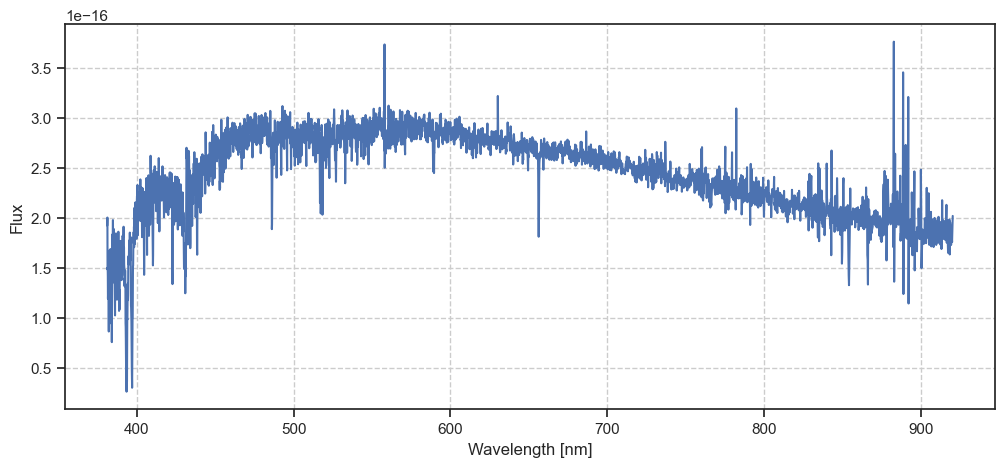

In [54]:
import astropy.units as u

spectra = SDSS.get_spectra(
    plate=sdss_query_result["plate"][0],
    mjd=sdss_query_result["mjd"][0],
    fiberID=sdss_query_result["fiberID"][0],
    data_release=13,
)

data = spectra[0][1].data


wavelength = 0.1 * 10 ** data["loglam"]
flux = data["flux"] * 1e-17 * u.erg / (u.cm**2 * u.s * u.AA)
 
plt.figure(figsize=(12, 5))
plt.plot(wavelength, flux)
plt.xlabel("Wavelength [nm]")
plt.ylabel("Flux")
plt.show()

 Mostrar el Gráfico

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# 1. We must force the raw FITS arrays into a DataFrame for Seaborn
spectrum_df = pd.DataFrame({
    'Wavelength': 10 ** spec_data['loglam'],
    'Flux': spec_data['flux']
})

# 2. Set the aesthetic theme globally (this replaces plt.grid and background tweaks)
sns.set_theme(style="ticks", rc={"axes.grid": True, "grid.linestyle": "--"})

plt.figure(figsize=(12, 5))

# 3. The Seaborn plot command
sns.lineplot(
    data=spectrum_df, 
    x='Wavelength', 
    y='Flux', 
    color='black', 
    linewidth=0.8
)

plt.ylabel(r"Flux ($10^{-17} \text{ erg/cm}^2\text{/s/\AA}$)")
plt.xlim(3800, 9200) 
plt.show()